<a href="https://colab.research.google.com/github/sanchezromeroaday-web/Computacional/blob/main/Obligatorio2_informe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulación del Modelo de Ising en 2D mediante el Método de Monte Carlo
**Informe de Física Computacional**

**Aday Sánchez Romero  
**Lenguaje de núcleo:** C++ (Cálculo) y Python (Visualización)

---
## 1. Objetivos del Estudio

1. **Análisis Visual y Transición de Fase:** Visualizar la evolución del sistema a diversas temperaturas mediante animaciones de la red.
2. **Magnetización vs. Temperatura:** Graficar el valor esperado de la magnetización $\langle M \rangle$ en función de la temperatura $T$.
## 2. Metodología: Conceptos Clave

Para simular este sistema sin tener que calcular el infinito número de estados posibles, utilizamos dos herramientas computacionales clave:

### El Método de Monte Carlo (Aceptación-Rechazo)
En lugar de evaluar absolutamente todas las configuraciones de la red , el método de **Monte Carlo** utiliza números aleatorios para tomar una "muestra representativa" del sistema.

El concepto de **Aceptación-Rechazo** funciona como un filtro: generamos configuraciones al azar y, mediante un criterio probabilístico, decidimos si esa configuración es válida para nuestro estudio (se acepta) o si se descarta (se rechaza).

---

### El Algoritmo de Metropolis
Es la regla de decisión que usamos para saber cómo evolucionan los espines con el tiempo y la temperatura. Funciona con esta lógica intuitiva:

1. **Elegimos un espín al azar** y calculamos qué pasaría con la energía del sistema si le cambiamos el signo (de +1 a -1, o viceversa).
2. **Si el cambio reduce la energía**, el cambio es favorable y lo **aceptamos siempre**. El sistema tiende naturalmente al orden.
3. **Si el cambio aumenta la energía**, no lo rechazamos inmediatamente. Lo aceptamos con una **cierta probabilidad que depende de la temperatura**.
   * A **temperaturas altas**, el sistema acepta muchos cambios desfavorables (mucha agitación térmica y desorden).
   * A **temperaturas bajas**, es casi imposible aceptar un aumento de energía (el sistema se congela en un estado ordenado).

### Simulación en C++: Generación de datos para la animación

**¿Qué hace este código exactamente?**
1. **Configuración Inicial:** Crea una red de 20x20 espines y les asigna un valor aleatorio de $+1$ o $-1$
2. **Condiciones de Contorno Periódicas:** Para evitar efectos de borde, la red se comporta como un toroide (la parte superior se conecta con la inferior, y la izquierda con la derecha).
3. **Evolución por Metropolis:** Durante 50000 iteraciones (pasos Monte Carlo), el programa elige espines al azar y decide si voltearlos o no evaluando el cambio de energía ($E$) y la temperatura ($T$).
4. **Exportación de Fotogramas:** Después de cada paso Monte Carlo completo, el estado de toda la red se guarda en el archivo `ising_data.dat`. Cada fotograma se separa con un doble salto de línea, dejándolo listo para que Python pueda leerlo y animarlo.

In [ ]:
%%writefile ising.cpp
#include <iostream>
#include <vector>
#include <cmath>
#include <cstdlib>
#include <fstream>

using namespace std;

int main() {
    int dim = 20;
    int iter = 50000;
    float T = 1.5;
    unsigned int seed = 1649176165;

    std::srand(seed);

    ofstream data_anim("ising_data.dat");

    // * CONFIGURACIÓN INICIAL (Fotograma 0) * //
    vector<vector<int>> s(dim, vector<int>(dim));
    for (int i = 0; i < dim; i++) {
        for (int j = 0; j < dim; j++) {
            s[i][j] = ((std::rand() % 2) == 0) ? -1 : 1;
            data_anim << s[i][j];
            if (j < dim - 1) data_anim << ",";
        }
        data_anim << "\n";
    }
    data_anim << "\n";

    // * ALGORITMO MONTE CARLO * //
    for (int k = 0; k < iter; k++) {
        for (int l = 0; l < dim * dim; l++) {
            int i = std::rand() % dim;
            int j = std::rand() % dim;

            int up = (i - 1 + dim) % dim;
            int down = (i + 1) % dim;
            int left = (j - 1 + dim) % dim;
            int right = (j + 1) % dim;

            int E = 2 * s[i][j] * (s[down][j] + s[up][j] + s[i][right] + s[i][left]);

            float p = std::exp(-E / T);
            if (p > 1.0f) p = 1.0f;

            float r = static_cast<float>(std::rand()) / RAND_MAX;

            if (r < p) s[i][j] *= -1;
        }

        // GUARDAMOS EL FOTOGRAMA
        for (int i = 0; i < dim; i++) {
            for (int j = 0; j < dim; j++) {
                data_anim << s[i][j];
                if (j < dim - 1) data_anim << ",";
            }
            data_anim << "\n";
        }
        // Salto de línea separador (excepto en el último fotograma)
        if (k < iter - 1) data_anim << "\n";
    }

    data_anim.close();
    return 0;
}

In [ ]:
!g++ -O3 ising.cpp -o ising_sim  # Compila
!./ising_sim                     # Ejecuta

## 3. Visualización y Animación con Python

Una vez generados los datos de la simulación mediante de cálculo en C++, utilizamos **Python** para la  visualización.

El código utilizado para procesar el archivo `ising_data.dat` y generar la animación de la red de espines ha sido obtenido  del repositorio de la asignatura **"fisicacomputacional"**, creado por la profesora **Jara Juana Bermejo-Vega**.

Esta visualización nos permite observar dinámicamente cómo el sistema busca alcanzar el equilibrio térmico y cómo se comportan los dominios de espines a la temperatura seleccionada.

In [ ]:
# ================================================================================
# ANIMACION ISING
#
# CURSO 2023-2024
# contenido
# Genera una animación a partir de un fichero de datos con la configuración
# del retículo en cada instante de tiempo
#
# El fichero debe estructurarse de la siguiente forma:
#
#   s(1,1)_1, s(1,2)_1, ..., s(1,M)_1
#   s(2,1)_1, s(2,2)_1, ..., s(2,M)_1
#   (...)
#   s(N,1)_1, s(N,2)_1, ..., s(N,M)_1
#
#   s(1,1)_2, s(1,2)_2, ..., s(1,M)_2,
#   s(2,1)_2, s(2,2)_2, ..., s(2,M)_2
#   (...)
#   s(N,1)_2, s(N,2)_2, ..., s(N,M)_2
#
#   s(1,1)_3, s(1,2)_3, ..., s(1,M)_3
#   s(2,1)_3, s(2,2)_3, ..., s(2,M)_3
#   (...)
#   s(N,1)_3, s(N,2)_3, ..., s(N,M)_3
#
#   (...)
#
# donde s(i,j)_k es el valor del spin en la fila i-ésima y la columna
# j-ésima en el instante k. M es el número de columnas y N el número
# de filas en el retículo. Los valores del spin deben ser +1 ó -1.
# El programa asume que las dimensiones del retículo no cambian a lo
# largo del tiempo.
#
# Si solo se especifica un instante de tiempo, se genera una imagen en pdf
# en lugar de una animación
#
# Se puede configurar la animación cambiando el valor de las variables
# de la sección "Parámetros"
#
# ================================================================================

# Importa los módulos necesarios
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
import io

# Parámetros
# ========================================
file_in = "ising_data.dat" # Nombre del fichero de datos
file_out = "ising" # Nombre del fichero de salida (sin extensión)
interval = 100 # Tiempo entre fotogramas en milisegundos
save_to_file = False # False: muestra la animación por pantalla,
                     # True: la guarda en un fichero
dpi = 150 # Calidad del vídeo de salida (dots per inch)


# Lectura del fichero de datos
# ========================================
# Lee el fichero a una cadena de texto
with open(file_in, "r") as f:
    data_str = f.read()

# Inicializa la lista con los datos de cada fotograma.
# frames_data[j] contiene los datos del fotograma j-ésimo
frames_data = list()

# Itera sobre los bloques de texto separados por líneas vacías
# (cada bloque corresponde a un instante de tiempo)
for frame_data_str in data_str.split("\n\n"):
    # Almacena el bloque en una matriz
    # (io.StringIO permite leer una cadena de texto como si fuera un
    # fichero, lo que nos permite usar la función loadtxt de numpy)
    frame_data = np.loadtxt(io.StringIO(frame_data_str), delimiter=",")

    # Añade los datos del fotograma (la configuración del sistema)
    # a la lista
    frames_data.append(frame_data)

# Creación de la animación/gráfico
# ========================================
# Crea los objetos figure y axis
fig, ax = plt.subplots()

# Define el rango de los ejes
ax.axis("off")  # No muestra los ejes

# Representa el primer fotograma
im = ax.imshow(frames_data[0], cmap="binary", vmin=-1, vmax=+1)

# Función que actualiza la configuración del sistema en la animación
def update(j_frame, frames_data, im):
    # Actualiza el gráfico con la configuración del sistema
    im.set_data(frames_data[j_frame])

    return im,

# Calcula el nº de frtogramas o instantes de tiempo
nframes = len(frames_data)

# Si hay más de un instante de tiempo, genera la animación
if nframes > 1:
    animation = FuncAnimation(
            fig, update,
            fargs=(frames_data, im), frames=len(frames_data), blit=True, interval=interval)

    # Muestra por pantalla o guarda según parámetros
    if save_to_file:
        animation.save("{}.mp4".format(file_out), dpi=dpi)
    else:
        plt.show()
# En caso contrario, muestra o guarda una imagen
else:
    # Muestra por pantalla o guarda según parámetros
    if save_to_file:
        fig.savefig("{}.pdf".format(file_out))
    else:
        plt.show()

## 4.Simulación en C++: Cálculo de la Magnetización vs. Temperatura

Para cumplir con el segundo objetivo del estudio, implementamos un nuevo script en C++ enfocado en obtener el valor esperado de la magnetización $\langle M \rangle$ en función de la temperatura $T$.

Las características clave de esta simulación son:

1. **Configuración inicial ordenada:** Partimos de una red donde todos los espines están perfectamente alineados ($s_{i,j} = +1$), lo que representa un estado ferromagnético puro de máxima magnetización.
2. **Termalización prolongada ($10^6$ pasos):** Para garantizar que el sistema alcance el verdadero equilibrio térmico a cada temperatura, dejamos evolucionar la red durante un millón de pasos de Monte Carlo.
3. **Barrido de Temperaturas:** El programa itera sobre un rango de temperaturas, prestando especial atención a la zona cercana a la temperatura crítica teórica. En cada punto, se promedia el valor absoluto de la magnetización por espín tras alcanzar el equilibrio.
4. **Exportación:** Los pares de datos obtenidos se guardan en un archivo, `magnetizacion_data.dat`, dejándolos listos para su posterior representación gráfica con Python.

In [ ]:
%%writefile ising_mag.cpp

#include <iostream>
#include <vector>
#include <cmath>
#include <cstdlib>
#include <fstream>

using namespace std;

int main() {
    int dim = 20;
    int iter = 1000000;     //  10^6 pasos Monte Carlo
    unsigned int seed = 12345;
    std::srand(seed);

    ofstream data_mag("magnetizacion_data.dat"); //

    // Bucle de temperaturas (de 1.0 a 4.0)
    for (float T = 1.0; T <= 4.0; T += 0.1) {

        // * ESTADO INICIAL ORDENADO (+1) * //
        vector<vector<int>> s(dim, vector<int>(dim, 1));

        float M_acumulado = 0; // Para promediar al final
        int pasos_medicion = 0;

        // * EVOLUCIÓN: PASOS MONTE CARLO * //
        for (int k = 0; k < iter; k++) {
            for (int l = 0; l < dim * dim; l++) {
                int i = std::rand() % dim;
                int j = std::rand() % dim;

                int up = (i - 1 + dim) % dim;
                int down = (i + 1) % dim;
                int left = (j - 1 + dim) % dim;
                int right = (j + 1) % dim;

                int E = 2 * s[i][j] * (s[down][j] + s[up][j] + s[i][right] + s[i][left]);

                float p = std::exp(-E / T);
                if (p > 1.0f) p = 1.0f;

                float r = static_cast<float>(std::rand()) / RAND_MAX;

                if (r < p) {
                    s[i][j] *= -1;
                }
            }

            //  Empezamos a medir M solo en el último 10% de los pasos
            if (k >= iter - 1000) {
                float M_paso = 0;
                for (int i = 0; i < dim; i++) {
                    for (int j = 0; j < dim; j++) {
                        M_paso += s[i][j];
                    }
                }
                M_acumulado += std::abs(M_paso) / (dim * dim);
                pasos_medicion++;
            }
        }

        // Promedio final de la magnetización a esta temperatura T
        float M_final = M_acumulado / pasos_medicion;

        // Guardar T y M en el archivo
        data_mag << T << "\t" << M_final << endl;
        cout << "Calculada T = " << T << " | M = " << M_final << endl; // Para ver el progreso
    }

    data_mag.close();
    return 0;
}

In [1]:
!g++ -O3 ising_mag.cpp -o simulacion
!./simulacion

cc1plus: fatal error: ising_mag.cpp: No such file or directory
compilation terminated.
/bin/bash: line 1: ./simulacion: No such file or directory


## 5. Representación de la Transición de Fase

Una vez que el núcleo de C++ ha finalizado el millón de pasos de Monte Carlo y ha exportado los promedios al archivo `magnetizacion_data.dat`, pasamos a la fase de visualización utilizando **Python** (`numpy` y `matplotlib`).

El objetivo de este bloque es graficar el valor esperado de la magnetización media frente a la temperatura para observar de forma directa la **transición de fase ferromagnética-paramagnética**.

Para evaluar la precisión de nuestra simulación, el código incluye una línea vertical roja que marca la **temperatura crítica teórica** hallada analíticamente por Lars Onsager para el modelo de Ising en 2D

A temperaturas $T < T_c$, el sistema mantiene un orden macroscópico (magnetización alta). Conforme nos acercamos a $T_c$, la agitación térmica vence a la interacción entre espines, haciendo que la magnetización caiga hacia cero.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Leer los datos del archivo generado por C++
# loadtxt automáticamente separa las columnas guiándose por los espacios/tabuladores
datos = np.loadtxt("magnetizacion_data.dat")

temperaturas = datos[:, 0]     # La primera columna es la Temperatura
magnetizaciones = datos[:, 1]  # La segunda columna es la Magnetización

# 2. Crear la gráfica
plt.figure(figsize=(8, 6))

# Dibujamos los puntos y la línea que los une
plt.plot(temperaturas, magnetizaciones, marker='o', color='blue', linestyle='-')

# Línea vertical roja para marcar visualmente dónde ocurre la transición de fase (T_c)
plt.axvline(x=2.27, color='red', linestyle='--', label='Temperatura Crítica (~2.27)')

# Decoración del gráfico
plt.title('Transición de Fase: Magnetización vs Temperatura', fontsize=14)
plt.xlabel('Temperatura (T)', fontsize=12)
plt.ylabel('Magnetización Media |m|', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

# Mostrar la obra de arte
plt.show()

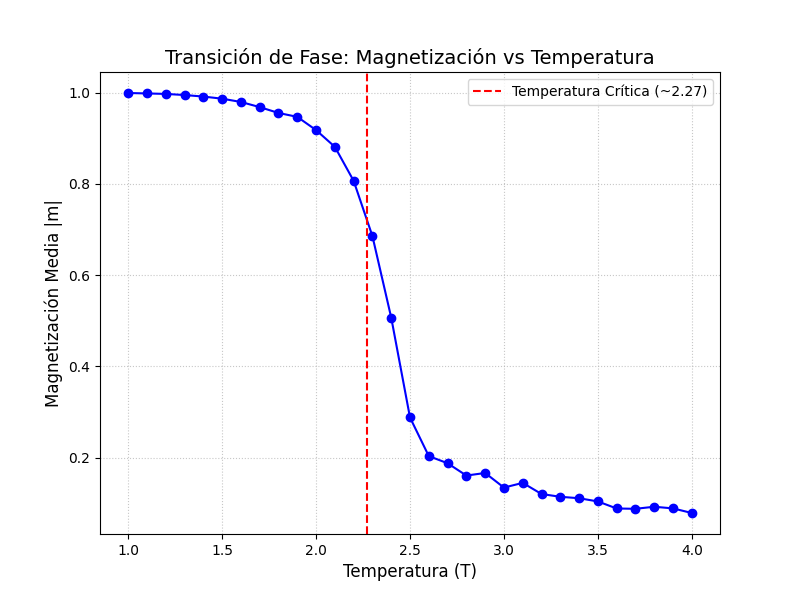